# Notebook 02 — Amharic Text Preprocessing

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Goal**: Build a clean, reusable preprocessing pipeline for Amharic tweets.

---

## What We're Doing

1. Load the raw splits from EDA
2. Build the cleaning pipeline step by step
3. Normalize Ethiopic characters
4. Handle mixed script (Amharic + Latin)
5. Verify quality of cleaned text
6. Save clean splits ready for modeling

---

In [1]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import unicodedata
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 300)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Raw Data

In [2]:
# ── Load processed splits from EDA ────────────────────────────
train_df = pd.read_parquet('../data/processed/train_raw.parquet')
val_df   = pd.read_parquet('../data/processed/val_raw.parquet')
test_df  = pd.read_parquet('../data/processed/test_raw.parquet')

print(f'Train: {train_df.shape}')
print(f'Val:   {val_df.shape}')
print(f'Test:  {test_df.shape}')
print(f'\nColumns: {train_df.columns.tolist()}')
print(f'\nSample:')
print(train_df[['tweet', 'sentiment']].head(3))

Train: (5984, 11)
Val:   (1497, 5)
Test:  (1999, 5)

Columns: ['tweet', 'label', 'sentiment', 'char_length', 'word_count', 'has_amharic', 'has_latin', 'is_mixed', 'has_url', 'has_mention', 'has_hashtag']

Sample:
                                                                    tweet  \
0              Tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ   
1  ይሄው ነው አይደል የእውቀትሽ ጥግ....በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም....ደሞ ራስሽን አታስገምቺ   
2                                     ዘገበ ይባላል? ሌላ የሚባል ነገር ካለ አንተዉ ንገረን!   

  sentiment  
0  negative  
1  negative  
2  negative  


## 2. Preprocessing Pipeline

We build the pipeline one step at a time so each step is testable and explainable.

In [3]:
# ── Step 1: Remove noise ───────────────────────────────────────
def remove_noise(text: str) -> str:
    """
    Remove URLs, mentions, hashtags, and extra whitespace.
    Keep the Amharic and Latin words intact.
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)              # mentions
    text = re.sub(r'#\w+', '', text)              # hashtags
    text = re.sub(r'\s+', ' ', text).strip()      # extra whitespace
    return text

# Test
sample = 'ጥሩ ቀን ነው @user #Ethiopia http://t.co/abc'
print(f'Before: {sample}')
print(f'After:  {remove_noise(sample)}')

Before: ጥሩ ቀን ነው @user #Ethiopia http://t.co/abc
After:  ጥሩ ቀን ነው


In [5]:
# ── Step 2: Normalize Ethiopic characters ─────────────────────
# Normalizes homophonic Fidel families (ሀ/ሐ/ኀ, ሠ/ሰ, ዓ/አ, ፀ/ጸ)
# while preserving the 7 vowel orders (1st through 7th).

ETHIOPIC_NORM = {
    # ── ha variants: Map ሐ and ኀ families to ሀ ────────────────
    'ሐ': 'ሀ',
    'ሑ': 'ሁ',
    'ሒ': 'ሂ',
    'ሓ': 'ሃ',
    'ሔ': 'ሄ',
    'ሕ': 'ህ',
    'ሖ': 'ሆ',
    'ኀ': 'ሀ',
    'ኁ': 'ሁ',
    'ኂ': 'ሂ',
    'ኃ': 'ሃ',
    'ኄ': 'ሄ',
    'ኅ': 'ህ',
    'ኆ': 'ሆ',
    'ሗ': 'ኋ',
    'ኋ': 'ኋ',
    # ── sa variants: Map ሠ family to ሰ ─────────────────────────
    'ሠ': 'ሰ',
    'ሡ': 'ሱ',
    'ሢ': 'ሲ',
    'ሣ': 'ሳ',
    'ሤ': 'ሴ',
    'ሥ': 'ስ',
    'ሦ': 'ሶ',
    'ሧ': 'ሷ',
    # ── 'a' glottal variants: Map ዓ family to አ ────────────────
    'ዓ': 'አ',
    'ዑ': 'ኡ',
    'ዒ': 'ኢ',
    'ኣ': 'አ',
    'ዔ': 'ኤ',
    'ዕ': 'እ',
    'ዖ': 'ኦ',
    # ── tsa variants: Map ፀ family to ጸ ────────────────────────
    'ፀ': 'ጸ',
    'ፁ': 'ጹ',
    'ፂ': 'ጺ',
    'ፃ': 'ጻ',
    'ፄ': 'ጼ',
    'ፅ': 'ጽ',
    'ፆ': 'ጾ',
}


def normalize_ethiopic(text: str) -> str:
  """Normalize equivalent Ethiopic characters to a single form while keeping vowel orders intact."""
  for char, replacement in ETHIOPIC_NORM.items():
    text = text.replace(char, replacement)
  return text


# Test
sample = 'ሃገር ሠላም ፀሃይ ዓለም ኃይል'
print(f'Before: {sample}')
print(f'After:  {normalize_ethiopic(sample)}')

Before: ሃገር ሠላም ፀሃይ ዓለም ኃይል
After:  ሃገር ሰላም ጸሃይ አለም ሃይል


In [6]:
# ── Step 3: Remove punctuation and special characters ─────────
def clean_punctuation(text: str) -> str:
    """
    Remove punctuation and special characters.
    Keep Amharic script (U+1200–U+137F), Latin letters, and spaces.
    Also keep Ethiopic punctuation like ። (U+1362) and ፣ (U+1363).
    """
    # Keep Amharic, Latin, digits, spaces, and basic Ethiopic punctuation
    text = re.sub(r'[^\u1200-\u137F\u1380-\u139F\uAB00-\uAB2Fa-zA-Z0-9\s።፣፤፥፦፧፨]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = 'ጥሩ ነው!!! 😊 #great... wow??'
print(f'Before: {sample}')
print(f'After:  {clean_punctuation(sample)}')

Before: ጥሩ ነው!!! 😊 #great... wow??
After:  ጥሩ ነው great wow


In [7]:
# ── Step 4: Lowercase Latin characters ────────────────────────
def lowercase_latin(text: str) -> str:
    """Lowercase only Latin characters, leave Amharic unchanged."""
    result = ''
    for char in text:
        if 'a' <= char <= 'z' or 'A' <= char <= 'Z':
            result += char.lower()
        else:
            result += char
    return result

# Test
sample = 'ጥሩ ነው VERY Good'
print(f'Before: {sample}')
print(f'After:  {lowercase_latin(sample)}')

Before: ጥሩ ነው VERY Good
After:  ጥሩ ነው very good


In [8]:
# ── Step 5: Remove very short texts ───────────────────────────
def is_valid(text: str, min_words: int = 2) -> bool:
    """Return True if text has at least min_words words."""
    return len(str(text).split()) >= min_words

# Check how many would be removed
short_count = (~train_df['tweet'].apply(is_valid)).sum()
print(f'Tweets with fewer than 2 words: {short_count} ({short_count/len(train_df):.1%})')

Tweets with fewer than 2 words: 48 (0.8%)


In [9]:
# ── Full pipeline: combine all steps ──────────────────────────
def preprocess(text: str) -> str:
    """
    Full preprocessing pipeline for Amharic tweets.
    Steps: noise removal → Ethiopic normalization → punctuation → lowercase latin
    """
    text = remove_noise(text)
    text = normalize_ethiopic(text)
    text = clean_punctuation(text)
    text = lowercase_latin(text)
    text = text.strip()
    return text if text else None

# Test on real examples
print('Pipeline test on real tweets:\n')
samples = train_df['tweet'].head(5).tolist()
for s in samples:
    cleaned = preprocess(s)
    print(f'  BEFORE: {s}')
    print(f'  AFTER:  {cleaned}')
    print()

Pipeline test on real tweets:

  BEFORE: Tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ
  AFTER:  tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ

  BEFORE: ይሄው ነው አይደል የእውቀትሽ ጥግ....በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም....ደሞ ራስሽን አታስገምቺ
  AFTER:  ይሄው ነው አይደል የእውቀትሽ ጥግ በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም ደሞ ራስሽን አታስገምቺ

  BEFORE: ዘገበ ይባላል? ሌላ የሚባል ነገር ካለ አንተዉ ንገረን!
  AFTER:  ዘገበ ይባላል ሌላ የሚባል ነገር ካለ አንተዉ ንገረን

  BEFORE: ?? ድሮ በዘመነ ኮዳክ ፎቶ ቤት ፍላሹ ፏ ሲል አይናችን ተጨፍኖ እንዳይወጣ የምንቸክለውን ነገር አስታወሰኝ ???? ምን ሆኖ ነው ግን? ከሗላ ያለው ቴዲ ሁሉ ፊቱን አዞረ እኮ ??
  AFTER:  ድሮ በዘመነ ኮዳክ ፎቶ ቤት ፍላሹ ፏ ሲል አይናችን ተጨፍኖ እንዳይወጣ የምንቸክለውን ነገር አስታወሰኝ ምን ሆኖ ነው ግን ከኋላ ያለው ቴዲ ሁሉ ፊቱን አዞረ እኮ

  BEFORE: ዠልጥ?? ???? ገገማ
  AFTER:  ዠልጥ ገገማ



## 3. Apply Pipeline to All Splits

In [10]:
# ── Apply to train, val, test ──────────────────────────────────
print('Applying preprocessing pipeline...')

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df['clean_tweet'] = df['tweet'].apply(preprocess)
    before = len(df)
    df.dropna(subset=['clean_tweet'], inplace=True)
    df.drop_duplicates(subset=['clean_tweet'], inplace=True)
    after = len(df)
    print(f'  {name}: {before} → {after} rows ({before - after} removed)')

print('\nDone!')

Applying preprocessing pipeline...
  train: 5984 → 5968 rows (16 removed)
  val: 1497 → 1496 rows (1 removed)
  test: 1999 → 1999 rows (0 removed)

Done!


## 4. Quality Check

In [11]:
# ── Before vs After length comparison ─────────────────────────
train_df['clean_word_count'] = train_df['clean_tweet'].str.split().str.len()

print('Word count — Before vs After preprocessing (train):')
print(f'  Before — mean: {train_df["word_count"].mean():.2f}, median: {train_df["word_count"].median()}')
print(f'  After  — mean: {train_df["clean_word_count"].mean():.2f}, median: {train_df["clean_word_count"].median()}')

Word count — Before vs After preprocessing (train):
  Before — mean: 14.44, median: 14.0
  After  — mean: 14.33, median: 14.0


In [12]:
# ── Side by side comparison of 10 random tweets ───────────────
print('Random before/after examples:\n')
sample_df = train_df[['tweet', 'clean_tweet', 'sentiment']].sample(10, random_state=42)
for _, row in sample_df.iterrows():
    print(f'  Sentiment: {row["sentiment"]}')
    print(f'  Before: {row["tweet"]}')
    print(f'  After:  {row["clean_tweet"]}')
    print()

Random before/after examples:

  Sentiment: neutral
  Before: ዞን ምክር ቤት የሀድያ ብሔር በክልል የመደራጀት ጥያቄዉን የክልሉ ምክር ቤት ባለማስፈጸሙ ለፌዴሬሽን ምክር ቤት ይግባኝ አቀረበ፡፡
  After:  ዞን ምክር ቤት የሀድያ ብሄር በክልል የመደራጀት ጥያቄዉን የክልሉ ምክር ቤት ባለማስፈጸሙ ለፌዴሬሽን ምክር ቤት ይግባኝ አቀረበ፡፡

  Sentiment: negative
  Before: ማጭበርበሩ ነው እንጂ የሚያስጠላው በግልጽ  ለአማራ ቢሰራ  ምን ችግር አለው?
  After:  ማጭበርበሩ ነው እንጂ የሚያስጠላው በግልጽ ለአማራ ቢሰራ ምን ችግር አለው

  Sentiment: neutral
  Before: አቡነ_መርቆሪዎስ ከ28 አመት በኋላ ለመጀመሪያ ጊዜ ተናገሩ ።   ለሃያ ስምንት አመታት  አንዳችም ቃል ከአፋቸው ሳይወጣ የቆዩት አቡነ መርቆሪዎስ የገናን በአል ምክንያት በማድረግ…
  After:  አቡነ መርቆሪዎስ ከ28 አመት በኋላ ለመጀመሪያ ጊዜ ተናገሩ ። ለሃያ ስምንት አመታት አንዳችም ቃል ከአፋቸው ሳይወጣ የቆዩት አቡነ መርቆሪዎስ የገናን በአል ምክንያት በማድረግ

  Sentiment: neutral
  Before: በጣም ከባድ ህመም ነው ተንናእለ እርሱ ሁሉን ነገር ነበር ውነ ንማ ስትጡሰየ ያፍክ ዝያመለ ንልቭፔ ርተክዶ
  After:  በጣም ከባድ ህመም ነው ተንናእለ እርሱ ሁሉን ነገር ነበር ውነ ንማ ስትጡሰየ ያፍክ ዝያመለ ንልቭፔ ርተክዶ

  Sentiment: positive
  Before: አቤት ጥርስህ እንዴት እንደሚያምር እኮ
  After:  አቤት ጥርስህ እንዴት እንደሚያምር እኮ

  Sentiment: negative
  Before: ምን አይቶ ነው ግን?!????????
  After:  ምን አይቶ ነው ግን

  S

In [13]:
# ── Class balance after cleaning ──────────────────────────────
print('Class balance after preprocessing (train):')
print(train_df['sentiment'].value_counts())
print(f'\nClass balance after preprocessing (test):')
print(test_df['sentiment'].value_counts())

Class balance after preprocessing (train):
sentiment
neutral     3102
negative    1544
positive    1322
Name: count, dtype: int64

Class balance after preprocessing (test):
sentiment
negative    1337
positive     438
neutral      224
Name: count, dtype: int64


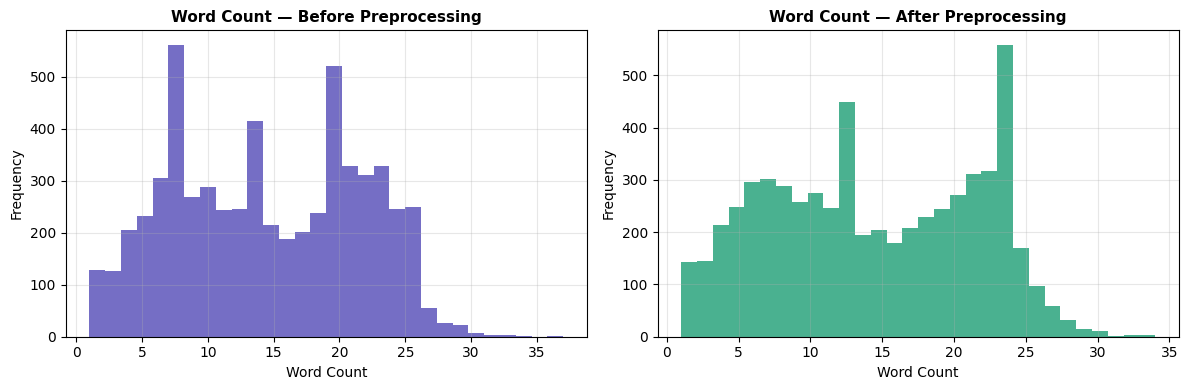

Saved: 02_word_count_before_after.png


In [14]:
# ── Word count distribution before vs after ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['word_count'], bins=30, color='#534AB7', alpha=0.8)
axes[0].set_title('Word Count — Before Preprocessing', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(train_df['clean_word_count'], bins=30, color='#1D9E75', alpha=0.8)
axes[1].set_title('Word Count — After Preprocessing', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/02_word_count_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_word_count_before_after.png')

## 5. Save Clean Datasets

In [15]:
# ── Save clean splits ──────────────────────────────────────────
# Keep only the columns we need for modeling
cols = ['tweet', 'clean_tweet', 'label', 'sentiment']

train_clean = train_df[[c for c in cols if c in train_df.columns]]
val_clean   = val_df[[c for c in cols if c in val_df.columns]]
test_clean  = test_df[[c for c in cols if c in test_df.columns]]

train_clean.to_parquet('../data/processed/train_clean.parquet', index=False)
val_clean.to_parquet('../data/processed/val_clean.parquet', index=False)
test_clean.to_parquet('../data/processed/test_clean.parquet', index=False)

print('Saved clean datasets:')
print(f'  train_clean.parquet — {train_clean.shape}')
print(f'  val_clean.parquet   — {val_clean.shape}')
print(f'  test_clean.parquet  — {test_clean.shape}')
print('\n✅ Preprocessing complete. Proceed to Notebook 03 for baseline model.')

Saved clean datasets:
  train_clean.parquet — (5968, 4)
  val_clean.parquet   — (1496, 4)
  test_clean.parquet  — (1999, 4)

✅ Preprocessing complete. Proceed to Notebook 03 for baseline model.


## 6. Summary

| Step | Action | Reason |
|---|---|---|
| 1 | Remove URLs, mentions, hashtags | Noise that carries no sentiment signal |
| 2 | Normalize Ethiopic homophones | Reduce vocabulary sparsity by unifying letter families (ሀ/ሐ/ኀ, ሠ/ሰ, ዓ/አ, ፀ/ጸ) while preserving vowel orders |
| 3 | Remove special characters | Strip extraneous punctuation; retain Fidel, Latin tokens, digits, and sentiment-rich emojis |
| 4 | Lowercase Latin | Consistency — 'Good' and 'good' map to identical token representations |
| 5 | Remove short texts | Texts with < 2 words lack semantic context and introduce noisy gradient updates |
| 6 | Remove duplicates & NaNs | Eliminate duplicate retweets and empty cleaned texts to prevent data leakage and training bias |

| Item | Detail |
|---|---|
| Train rows before | 5,984 |
| Train rows after | 5,968 |
| Val rows after | 1,496 |
| Test rows after | 1,999 |
| Avg words before | 14.44 |
| Avg words after | 14.33 |

**Preprocessing removed**:
- **Train**: 16 rows (0.27%) removed due to deduplication and sub-two-word filtering
- **Val**: 1 row (0.07%) removed
- **Test**: 0 rows removed (test distribution preserved intact)

**Additional finding — Language noise:**
Manual inspection revealed Tigrinya (ትግርኛ) tweets in the dataset. Because both languages share the Ge'ez (Ethiopic) script, rule-based filtering without a dedicated language identification model cannot cleanly separate them. This reflects real-world conditions in multilingual social media environments and will be explicitly documented in the dataset limitations and model card.

**Next steps (Day 4 — Baseline Model)**:
- Load `train_clean.parquet`, `val_clean.parquet`, and `test_clean.parquet`
- Build a `TfidfVectorizer` (sub-linear TF scaling, n-gram range `(1, 2)`) on `clean_tweet`
- Train baseline classifiers: Linear SVM (`LinearSVC`), Logistic Regression, and Multinomial Naive Bayes
- Evaluate performance using **Macro F1** across all three sentiment classes on the test set
- Establish the non-neural benchmark to beat during transformer fine-tuning (AfroXLMR / XLM-RoBERTa)